In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
fraud_df.info()
fraud_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


(151112, 11)

In [4]:
fraud_df.isnull().sum()


user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [6]:
fraud_df.duplicated().sum()
fraud_df = fraud_df.drop_duplicates()


In [8]:
fraud_df["signup_time"] = pd.to_datetime(
    fraud_df["signup_time"]
)
fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)


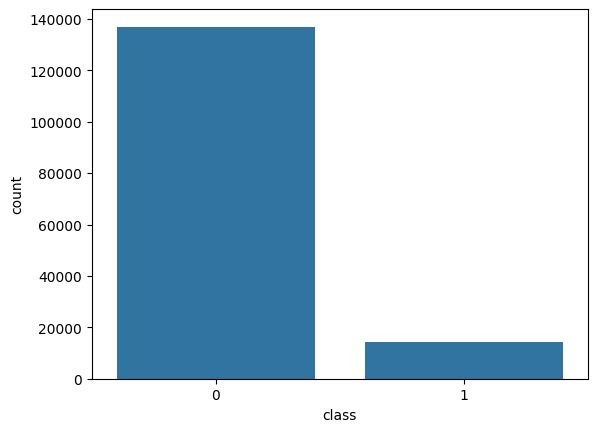

In [9]:
fraud_df["class"].value_counts()
sns.countplot(
    x="class",
    data=fraud_df
)
plt.show()

<Axes: >

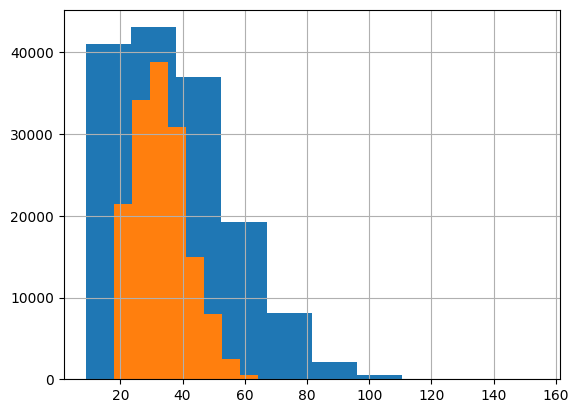

In [11]:
fraud_df["purchase_value"].hist()
fraud_df["age"].hist()

<Axes: xlabel='browser', ylabel='count'>

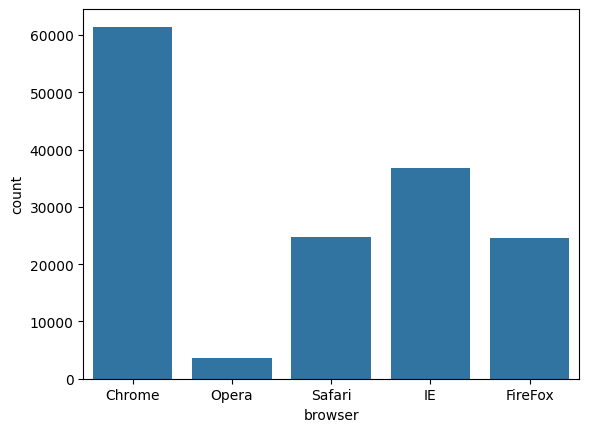

In [12]:
sns.countplot(
    x="browser",
    data=fraud_df
)

In [13]:
browser_fraud = pd.crosstab(
    fraud_df["browser"],
    fraud_df["class"],
    normalize="index"
)

browser_fraud

class,0,1
browser,,
Chrome,0.901208,0.098792
FireFox,0.904835,0.095165
IE,0.913225,0.086775
Opera,0.910773,0.089227
Safari,0.909799,0.090201


In [14]:
source_fraud = pd.crosstab(
    fraud_df["source"],
    fraud_df["class"],
    normalize="index"
)

<Axes: xlabel='class', ylabel='purchase_value'>

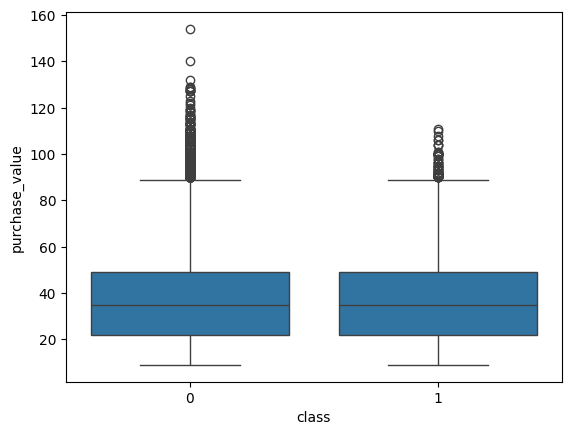

In [15]:
sns.boxplot(
    x="class",
    y="purchase_value",
    data=fraud_df
)

In [16]:
fraud_df["ip_address"] = (
    fraud_df["ip_address"]
    .astype(np.int64)
)

In [17]:
ip_df["lower_bound_ip_address"] = (
    ip_df["lower_bound_ip_address"]
    .astype(np.int64)
)

ip_df["upper_bound_ip_address"] = (
    ip_df["upper_bound_ip_address"]
    .astype(np.int64)
)

In [18]:
fraud_df = fraud_df.sort_values(
    "ip_address"
)

ip_df = ip_df.sort_values(
    "lower_bound_ip_address"
)

In [19]:
merged_df = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [20]:
merged_df = merged_df[
    merged_df["ip_address"]
    <= merged_df["upper_bound_ip_address"]
]

In [21]:
country_fraud = (
    merged_df.groupby("country")
    ["class"]
    .mean()
    .sort_values(ascending=False)
)

<Axes: xlabel='country'>

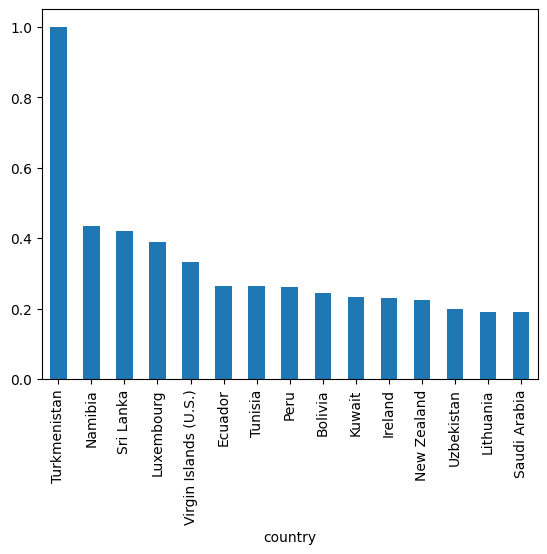

In [22]:
country_fraud.head(15).plot(
    kind="bar"
)